# Cluster1.ipynb

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MeanShift, SpectralClustering
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.datasets import make_moons # make_blobs is also useful

This code is based on Ivezić Section 6.4, but with expanded material.  
First, generate a dataset consisting of three subpopulations of 2D normal distributions, overlapping in $(x,y)$ space.

In [98]:
np.random.seed(0)

#xy1 = np.random.normal(size=(300,2),loc=(-1,-1)) # 300 points in 2 dimensions
#xy2 = np.random.normal(size=(300,2),loc=(1,1)) # 300 points in 2 dimensions
#xy3 = np.random.normal(size=(300,2),loc=(2,-2)) # 300 points in 2 dimensions

# sklearn.datasets.makeblobs() would be an alternative way to generate this dataset

mean_xy1 = np.array([-1,-1])
sigma_x, sigma_y, sigma_xy = 1.5, 1.5, -1**2
cov = np.array([[sigma_x**2,sigma_xy],[sigma_xy,sigma_y**2]])
xy1 = np.random.multivariate_normal(mean_xy1,cov,size=300) 

mean_xy2 = np.array([1,1])
sigma_x, sigma_y, sigma_xy = 1.5, 1.5, 1**2
cov = np.array([[sigma_x**2,sigma_xy],[sigma_xy,sigma_y**2]])
xy2 = np.random.multivariate_normal(mean_xy2,cov,size=300) 

mean_xy3 = np.array([2,-2])
sigma_x, sigma_y, sigma_xy = 1.0, 1.0, 0
cov = np.array([[sigma_x**2,sigma_xy],[sigma_xy,sigma_y**2]])
xy3 = np.random.multivariate_normal(mean_xy3,cov,size=300) 

X = np.concatenate((xy1,xy2,xy3))
x, y = X[:,0], X[:,1]

np.savetxt('test_data.csv',X)

Generating dataset for assignment

In [123]:
np.random.seed(5)

#xy1 = np.random.normal(size=(300,2),loc=(-1,-1)) # 300 points in 2 dimensions
#xy2 = np.random.normal(size=(300,2),loc=(1,1)) # 300 points in 2 dimensions
#xy3 = np.random.normal(size=(300,2),loc=(2,-2)) # 300 points in 2 dimensions

# sklearn.datasets.makeblobs() would be an alternative way to generate this dataset

mean_xy1 = np.array([-5,3])
sigma_x, sigma_y, sigma_xy = 2, 1.5, -1**2
cov = np.array([[sigma_x**2,sigma_xy],[sigma_xy,sigma_y**2]])
xy1 = np.random.multivariate_normal(mean_xy1,cov,size=300) 

mean_xy2 = np.array([1,2])
sigma_x, sigma_y, sigma_xy = 3, 1.5, 1**2
cov = np.array([[sigma_x**2,sigma_xy],[sigma_xy,sigma_y**2]])
xy2 = np.random.multivariate_normal(mean_xy2,cov,size=300) 

mean_xy3 = np.array([5,-1.5])
sigma_x, sigma_y, sigma_xy = 4.0, 1.0, 0
cov = np.array([[sigma_x**2,sigma_xy],[sigma_xy,sigma_y**2]])
xy3 = np.random.multivariate_normal(mean_xy3,cov,size=300) 

mean_xy4 = np.array([10,2])
sigma_x, sigma_y, sigma_xy = 3.0, 1.0, 1
cov = np.array([[sigma_x**2,sigma_xy],[sigma_xy,sigma_y**2]])
xy4 = np.random.multivariate_normal(mean_xy4,cov,size=300) 

X = np.concatenate((xy1,xy2,xy3,xy4))
x, y = X[:,0], X[:,1]

np.savetxt('test_data.csv',X)

Text(0.5, 1.0, 'original data/clusters')

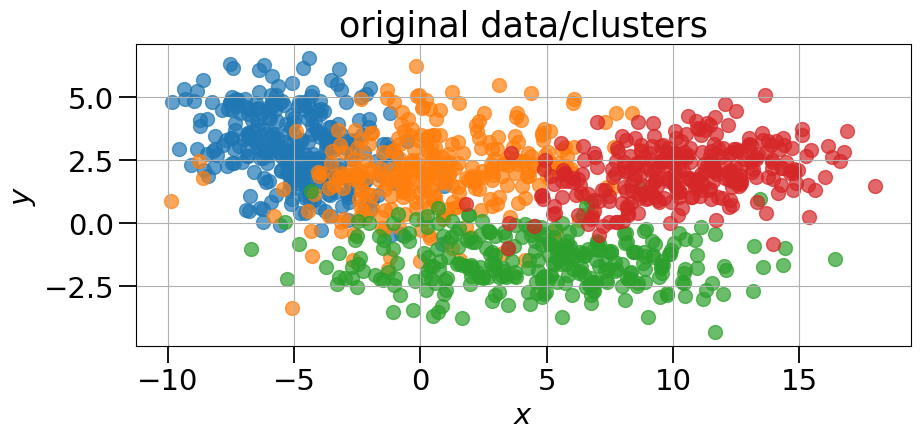

In [124]:
fig1 = plt.figure(figsize=(10,10))
plt.axes().set_aspect('equal')
plt.scatter(xy1[:,0],xy1[:,1],s=100,alpha=0.7)
plt.scatter(xy2[:,0],xy2[:,1],s=100,alpha=0.7)
plt.scatter(xy3[:,0],xy3[:,1],s=100,alpha=0.7)
plt.scatter(xy4[:,0],xy4[:,1],s=100,alpha=0.7)
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid('on')
plt.title('original data/clusters')
#plt.savefig('Ivezic_Sec6_4_fig2.png')

Now run $K$-means clustering.

In [101]:
clf = KMeans(n_clusters=3)
clf.fit(X)
print(clf)
centers = clf.cluster_centers_ # locations of the clusters
print(centers) # results are similar to original input centers
labels = clf.predict(X) # labels for each of the points
#print(labels)

KMeans(n_clusters=3)
[[10.4031794  10.03234852]
 [-0.23289627  1.10708109]
 [ 6.38193636 -0.75892289]]


Manually check the least-squares objective sums of the clusters (see Ivezić equation 6.28; could also be coded as simple sum of squares of $x$ and $y$ differences).

In [102]:
obj_sum = 0.0
for k in range(3) :
    group_k = np.where(labels==k)[0]
    # try alternatively these?: scipy.spatial.distance.cdist, scipy.cluster.vq.vq
    obj_sum_group_k = sum(np.linalg.norm(X[group_k]-centers[k],axis=1)**2) # sum of variance W_k
    print("group #%d, objective sum = %.3f" % (k,obj_sum_group_k) )
    obj_sum += obj_sum_group_k
print('objective sum = %.3f' % obj_sum )
print('inertia = %.3f' % clf.inertia_)

group #0, objective sum = 2655.498
group #1, objective sum = 4686.820
group #2, objective sum = 2747.597
objective sum = 10089.915
inertia = 10089.915


In [103]:
plt.rcParams.update({'font.size': 21})

Text(0.5, 1.0, 'original data/clusters')

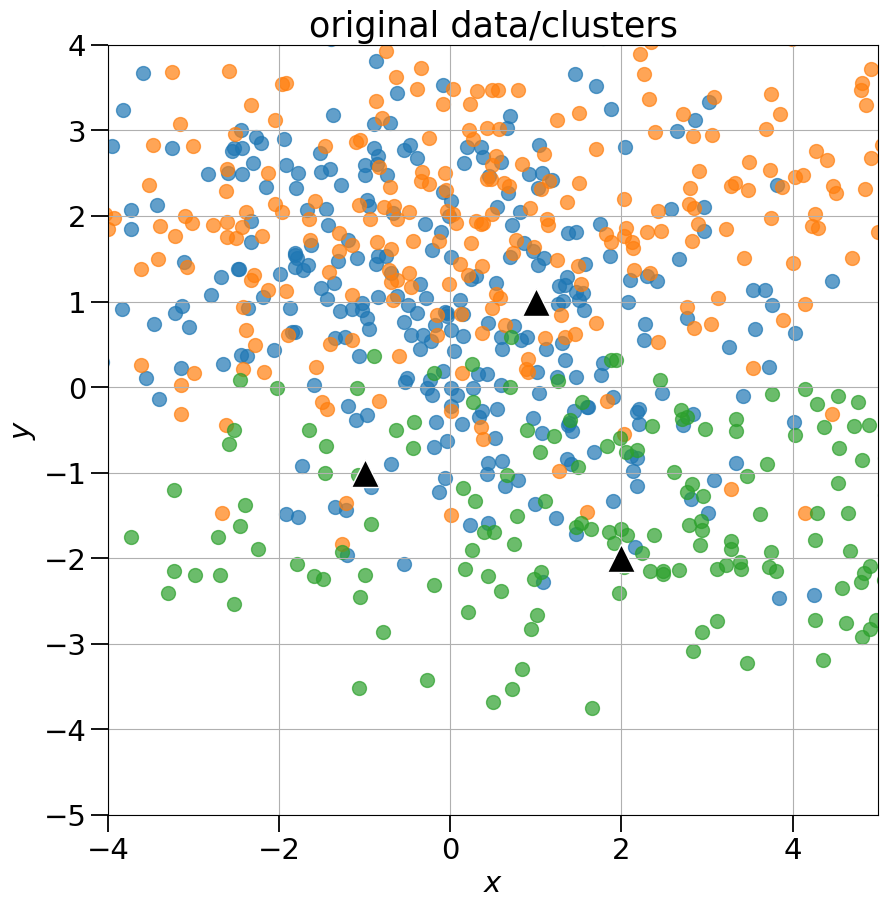

In [104]:
fig1 = plt.figure(figsize=(10,10))
plt.axes().set_aspect('equal')
plt.scatter(xy1[:,0],xy1[:,1],s=100,alpha=0.7)
plt.scatter(xy2[:,0],xy2[:,1],s=100,alpha=0.7)
plt.scatter(xy3[:,0],xy3[:,1],s=100,alpha=0.7)
plt.plot([-1,1,2],[-1,1,-2],'^k',mec='white',ms=20)
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid('on')
plt.xlim(-4,5); plt.ylim(-5,4)
plt.title('original data/clusters')
#plt.savefig('Ivezic_Sec6_4_fig2.png')

Text(0.5, 1.0, 'NumPy histogram2d')

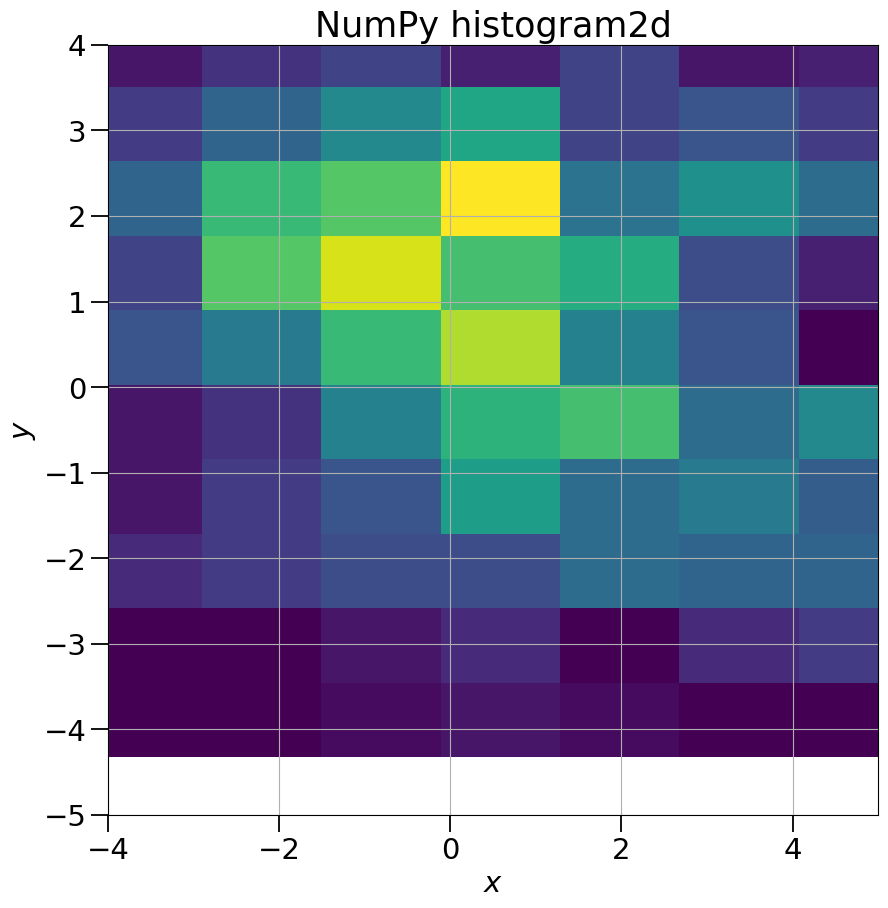

In [105]:
fig2 = plt.figure(figsize=(10,10))
plt.axes().set_aspect('equal')
H, xedges, yedges = np.histogram2d(x,y,20)
plt.imshow(H.T, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
# plt.pcolormesh allows for non-square bins
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.xlim(-4,5); plt.ylim(-5,4)
plt.grid('on')
plt.title('NumPy histogram2d')
#plt.savefig('Ivezic_Sec6_4_fig1.png')

Text(0.5, 1.0, 'sklearn KMeans')

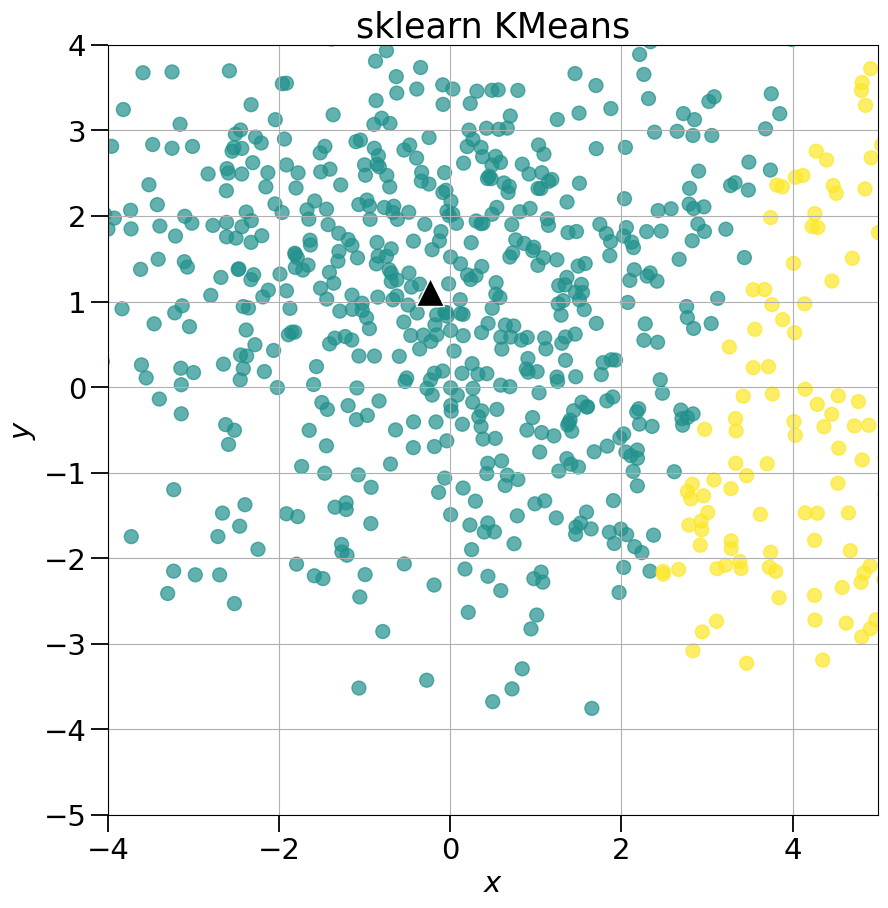

In [106]:
fig3 = plt.figure(figsize=(10,10))
plt.axes().set_aspect('equal')
plt.scatter(x,y,s=100,c=labels,alpha=0.7)
plt.plot(centers[:,0],centers[:,1],'^k',mec='white',ms=20)
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid('on')
plt.xlim(-4,5); plt.ylim(-5,4)
plt.title('sklearn KMeans')
#plt.savefig('Ivezic_Sec6_4_fig2.png')

Construct a grid showing the cluster boundaries.

In [107]:
x_grid = np.linspace(-4,5,50)
y_grid = np.linspace(-5,4,50)
XX, YY = np.meshgrid(x_grid,y_grid) # 50 x 50
XY = np.column_stack((np.ravel(XX),np.ravel(YY))) # 2500 x 2
labels2 = clf.predict(XY) # labels for each of the points
print(XY.shape)
labels_grid = labels2.reshape(XX.shape)

(2500, 2)


Text(0.5, 1.0, 'sklearn KMeans')

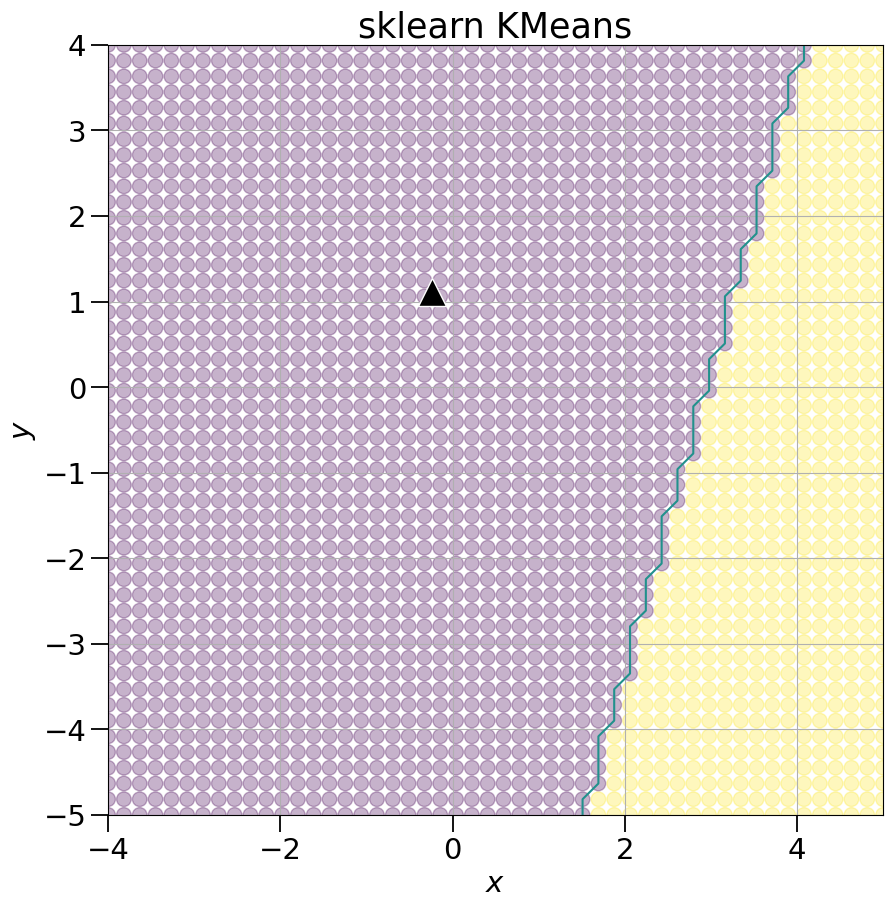

In [108]:
fig4 = plt.figure(figsize=(10,10))
plt.scatter(XY[:,0],XY[:,1],s=110,c=labels2,alpha=0.3)
plt.contour(XX,YY,labels_grid,levels=[0,1,2])
plt.plot(centers[:,0],centers[:,1],'^k',mec='white',ms=20)
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.xlim(-4,5); plt.ylim(-5,4)
plt.grid('on')
plt.title('sklearn KMeans')
#plt.savefig('Ivezic_Sec6_4_fig3.png')

In [109]:
# material on MeanShift and minimum spanning tree from 2022 omitted

This example from VanderPlas Section 5:

In [110]:
XM, labels_true = make_moons(200, noise=0.05, random_state=0)
print(labels_true)
labels_predict = KMeans(2, random_state=0).fit_predict(XM)
print(labels_predict)
diff = labels_predict - labels_true
print(diff)
print('out of 200, we get %d errors' % np.count_nonzero(diff))

[0 1 1 0 1 1 0 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1 0 1 1
 0 0 1 1 0 0 1 1 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 1 1
 1 0 1 0 0 1 1 0 1 1 1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 0 0 0 1 0 0 1 0 0
 0 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 0 0 0 1 1 1 1 0 1 0 1 1 0 0 0 0 1 1
 0 1 1 1 0 0 1 0 1 1 0 0 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1
 0 0 1 0 0 0 0 0 0 1 0 1 1 0 1]
[1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 1 0 0 1 1 0 1 0 0 1 1 0 0 1 0 1 0 1 1 1
 1 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 0 0 1 0 1 0
 1 0 0 1 0 1 1 0 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 0 1 0 0
 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 1 0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 0 1
 0 0 1 1 1 0 1 0 1 1 0 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1
 0 0 1 0 0 0 0 1 1 0 0 1 0 0 1]
[ 1  0 -1  0  0  0  1  0  1  0  0 -1  0  0  0  1  0  0  0  0  0  0  0  0
  0 -1  0  0 -1  0  1  0  0 -1  1  0  0  1  0 -1  0  0  0 -1  0  0  1  0
 -1  0  0  0  0  0  0  1  0  0  0  0  0 

Text(0.5, 1.0, 'sklearn KMeans')

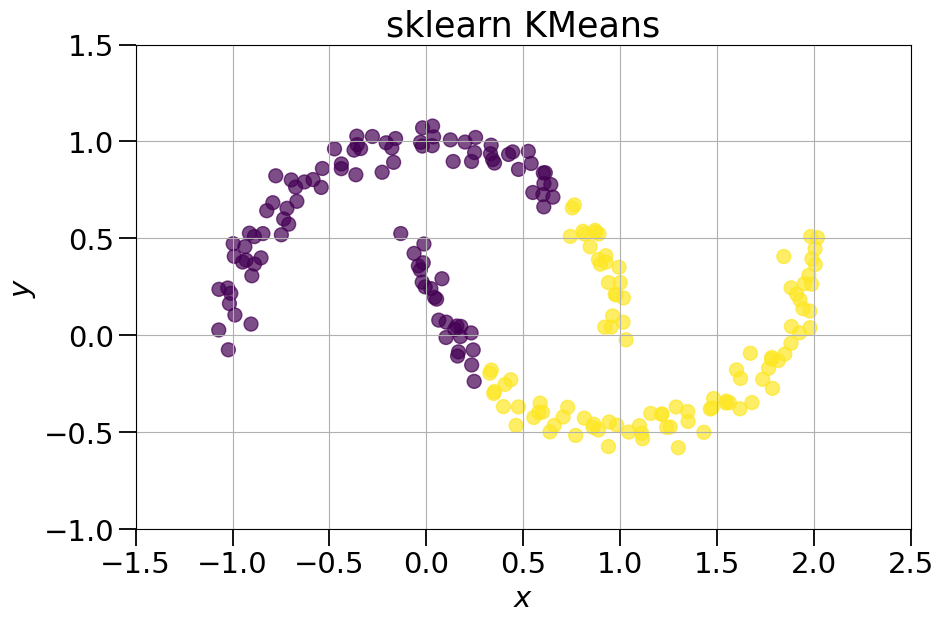

In [111]:
fig8 = plt.figure(figsize=(10,10))
plt.axes().set_aspect('equal')
plt.scatter(XM[:,0],XM[:,1],s=100,c=labels_predict,alpha=0.7)
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.xlim(-1.5,2.5); plt.ylim(-1.0,1.5)
plt.grid('on')
plt.title('sklearn KMeans')

Now try spectral clustering which uses a higher-dimensional representation of the data.

In [112]:
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans')
labels_predict2 = model.fit_predict(XM)

C:\Users\seosi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Text(0.5, 1.0, 'sklearn SpectralClustering')

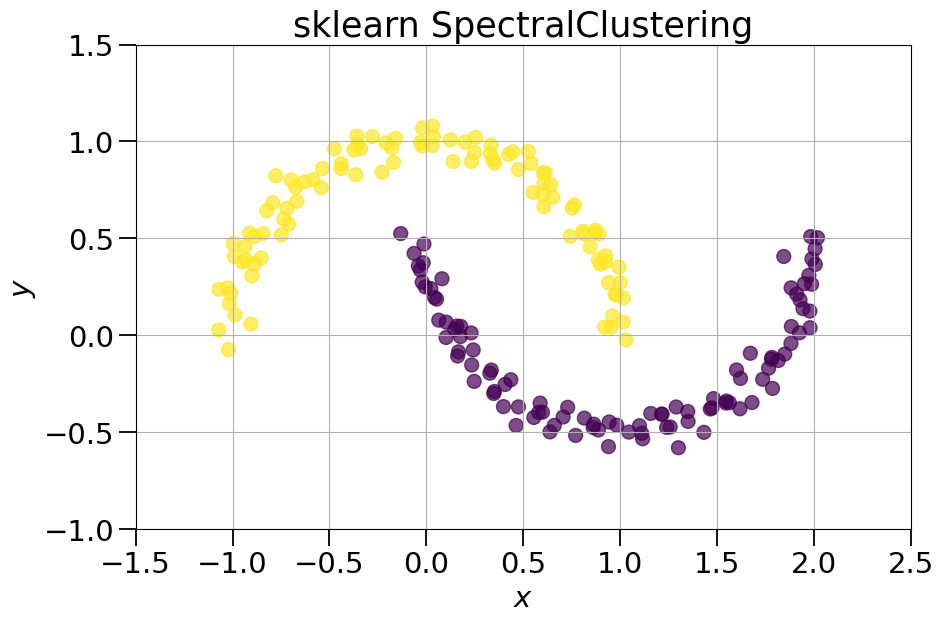

In [113]:
fig9 = plt.figure(figsize=(10,10))
plt.axes().set_aspect('equal')
plt.scatter(XM[:,0],XM[:,1],s=100,c=labels_predict2,alpha=0.7)
plt.tick_params('both', length=12, width=1.3, which='major')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.xlim(-1.5,2.5); plt.ylim(-1.0,1.5)
plt.grid('on')
plt.title('sklearn SpectralClustering')